<a href="https://colab.research.google.com/github/gakbn/ESCB-AngelGabrielAndradeAmezcua/blob/main/Lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Libreria SDV
*Autor: Alumno*
*Fecha: 04 de junio*

In [5]:
pip install sdv sdmetrics

In [6]:
import pandas as pd
import numpy as np
import random

In [7]:
import sdv
import sdmetrics

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [8]:
from sdmetrics.reports.single_table import QualityReport

In [9]:
print ("SDV",sdv.__version__)
print ("SDMetrics",sdmetrics.__version__)

SDV 1.37.0
SDMetrics 0.28.0


In [10]:
#Creamos un Dataset (original) que servira como una fuente para crear los datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id": [1,2,3,4,5,6,7,8,9,10],
        "edad": [23,33,43,28,53,56,43,56,65,40],
        "ingreso_mensual": [25000,15000,20000,10000,5000,17000,30000,12000,35000,7500],
        "ciudad": ["Veracruz","Cordoba","Paso del Macho","Amatlan","Fortin","Cuitlahuac","Yanga","Cordoba","Orizaba","Cuitlahuac"],
    }
)

In [11]:
dfClientes.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,1,23,25000,Veracruz
1,2,33,15000,Cordoba
2,3,43,20000,Paso del Macho
3,4,28,10000,Amatlan
4,5,53,5000,Fortin


In [12]:
#Definir metadatos
metadata = SingleTableMetadata()

In [13]:
metadata.detect_from_dataframe(
    data=dfClientes
    )

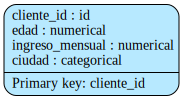

In [14]:
metadata.visualize()

In [15]:
metadata.to_dict()

{'primary_key': 'cliente_id',
 'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

In [16]:
#Guardamos en json
metadata.save_to_json(
    "dfClientes_metadata.json"
)

In [17]:
#Entrenamos el modelo para generar los datos sinteticos
synthesizer = GaussianCopulaSynthesizer(
    metadata
)


/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:182: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)


In [18]:
synthesizer.fit(dfClientes)

In [19]:
clientes_sinteticos = synthesizer.sample(
    num_rows=100
)

In [20]:
clientes_sinteticos.head()

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,62,24532,Cuitlahuac
1,4918803,33,29276,Fortin
2,1900081,40,17242,Cuitlahuac
3,531516,30,18748,Cuitlahuac
4,10211768,49,29878,Yanga


In [21]:
clientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       100 non-null    int64 
 1   edad             100 non-null    int64 
 2   ingreso_mensual  100 non-null    int64 
 3   ciudad           100 non-null    object
dtypes: int64(3), object(1)
memory usage: 3.3+ KB


In [22]:
clientes_sinteticos.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.000000e+02,100.000000,100.000000,100
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,Cuitlahuac
freq,NaN,NaN,NaN,27
mean,8.532170e+06,43.170000,21720.300000,NaN
std,4.687773e+06,12.249968,8959.601928,NaN
min,4.660500e+04,28.000000,6150.000000,NaN
25%,5.008268e+06,31.000000,13696.000000,NaN
50%,8.656048e+06,40.500000,22451.500000,NaN
75%,1.256688e+07,55.000000,29632.000000,NaN


In [23]:
#DataFrame contaminado
dfClientesGIGO =clientes_sinteticos.copy()

In [24]:
#Colocamos edades imposibles
indices = random.sample(list(dfClientesGIGO.index),5)

In [25]:
dfClientesGIGO.loc[indices,"edad"] = -5

In [27]:
#Introducir valores duplicados
duplicados = dfClientesGIGO.sample(10,random_state=42)

In [29]:
dfClientesGIGO = pd.concat([dfClientesGIGO,duplicados], ignore_index=True)

In [30]:
dfClientesGIGO.duplicated().sum()

np.int64(10)

In [31]:
dfClientesGIGO.describe(include="all")

,cliente_id,edad,ingreso_mensual,ciudad
count,1.100000e+02,110.000000,110.000000,110
unique,NaN,NaN,NaN,8
top,NaN,NaN,NaN,Cordoba
freq,NaN,NaN,NaN,31
mean,8.614045e+06,40.354545,21104.381818,NaN
std,4.775996e+06,15.471540,9130.476566,NaN
min,4.660500e+04,-5.000000,6150.000000,NaN
25%,4.948624e+06,30.000000,13530.250000,NaN
50%,8.956428e+06,38.500000,22080.500000,NaN
75%,1.274153e+07,53.750000,29467.750000,NaN


In [32]:
#Generar el reporte
reporte = QualityReport()

In [33]:
reporte.generate(
    real_data= dfClientes,
    synthetic_data = clientes_sinteticos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 329.92it/s]|
Column Shapes Score: 79.0%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 117.84it/s]|
Column Pair Trends Score: 17.0%

Overall Score (Average): 48.0%



In [34]:
reporte.generate(
    real_data= dfClientes,
    synthetic_data = dfClientesGIGO,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 284.79it/s]|
Column Shapes Score: 78.48%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 137.13it/s]|
Column Pair Trends Score: 15.0%

Overall Score (Average): 46.74%

